# Qwen3-VL-2B-Instruct Benchmark on val_data\n
\n
This notebook runs three checks for one VLM:\n
1. Dataset suitability/usability validation\n
2. Accuracy benchmark on val_data\n
3. Raw-attention visualization smoke test\n

In [ ]:
from pathlib import Path
import json
from pprint import pprint

from finesightbench.evaluation.framework import (
    validate_val_dataset,
    evaluate_model_on_val_data,
)

MODEL_NAME = "Qwen3-VL-2B-Instruct"
VAL_ROOT = Path("/home/snt/projects_lujun/FineSightBench/data/val_data")
OUTPUT_DIR = Path("/home/snt/projects_lujun/FineSightBench/outputs/vlm_eval")
MAX_SAMPLES_PER_SPLIT = 60   # set to -1 for full split
ALLOW_DOWNLOAD = False       # already cached locally

/home/snt/projects_lujun/FineSightBench/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
validation = validate_val_dataset(VAL_ROOT)
print(json.dumps({
    "dataset_usable": validation["dataset_usable"],
    "label_files": validation["label_files"],
    "raw_samples": validation["raw_samples"],
    "evaluable_samples": validation["evaluable_samples"],
    "missing_images": validation["missing_images"],
    "corrupted_images": validation["corrupted_images"],
}, indent=2, ensure_ascii=False))
print('\nSplit counts:')
pprint(validation['split_counts'])
print('\nTask counts:')
pprint(validation['task_counts'])

{
  "dataset_usable": true,
  "label_files": 5,
  "raw_samples": 2013,
  "evaluable_samples": 2013,
  "missing_images": 0,
  "corrupted_images": 0
}

Split counts:
{'perception': 875,
 'perception_custom': 40,
 'reasoning': 1050,
 'reasoning_custom': 40,
 'root': 8}

Task counts:
{'animal_recognition': 191,
 'block_recognition': 183,
 'chain_reasoning': 183,
 'color_block_recognition': 183,
 'comparison': 175,
 'counting': 183,
 'interference_blur': 183,
 'interference_cvd': 183,
 'letter_recognition': 183,
 'shape_recognition': 183,
 'spatial': 183}


In [5]:
report = evaluate_model_on_val_data(
    model_name=MODEL_NAME,
    val_root=VAL_ROOT,
    output_dir=OUTPUT_DIR,
    max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
    local_files_only=not ALLOW_DOWNLOAD,
    run_attention_test=True,
)

print(json.dumps({
    "model_name": report.get("model_name"),
    "model_id": report.get("model_id"),
    "status": report.get("status"),
    "accuracy": report.get("accuracy"),
    "num_evaluated": report.get("num_evaluated"),
    "num_successful_inference": report.get("num_successful_inference"),
    "attention_test": report.get("attention_test", {}),
    "error": report.get("error", ""),
}, indent=2, ensure_ascii=False))

Loading weights: 100%|██████████| 625/625 [00:01<00:00, 400.97it/s]
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{
  "model_name": "Qwen3-VL-2B-Instruct",
  "model_id": "Qwen/Qwen3-VL-2B-Instruct",
  "status": "ok",
  "accuracy": 0.49038461538461536,
  "num_evaluated": 208,
  "num_successful_inference": 208,
  "attention_test": {
    "status": "passed",
    "reason": "",
    "gif_path": "/home/snt/projects_lujun/FineSightBench/outputs/vlm_eval/Qwen3-VL-2B-Instruct/perception_color_block_32px_00654_attention.gif",
    "attention_shape": [
      28,
      16,
      245,
      245
    ],
    "num_tokens": 2,
    "model_answer": "blue",
    "question": "What color is the block in the image? Answer with one of: red, green, blue, yellow, cyan, magenta, orange, purple, pink, brown, gray.",
    "image_id": "perception_color_block_32px_00654"
  },
  "error": ""
}


In [6]:
print('accuracy_by_split:')
pprint(report.get('accuracy_by_split', {}))
print('\naccuracy_by_task:')
pprint(report.get('accuracy_by_task', {}))

if report.get('num_errors', 0) > 0:
    print(f"\nnum_errors: {report['num_errors']}")
    print('See report path:', Path(report['predictions_path']).parent / 'errors.json')

accuracy_by_split:
{'perception': {'accuracy': 0.7666666666666667, 'n': 60},
 'perception_custom': {'accuracy': 0.25, 'n': 40},
 'reasoning': {'accuracy': 0.55, 'n': 60},
 'reasoning_custom': {'accuracy': 0.175, 'n': 40},
 'root': {'accuracy': 0.75, 'n': 8}}

accuracy_by_task:
{'animal_recognition': {'accuracy': 0.6785714285714286, 'n': 28},
 'block_recognition': {'accuracy': 0.058823529411764705, 'n': 17},
 'chain_reasoning': {'accuracy': 0.26666666666666666, 'n': 15},
 'color_block_recognition': {'accuracy': 0.7222222222222222, 'n': 18},
 'comparison': {'accuracy': 0.7, 'n': 10},
 'counting': {'accuracy': 0.16666666666666666, 'n': 18},
 'interference_blur': {'accuracy': 0.6842105263157895, 'n': 19},
 'interference_cvd': {'accuracy': 0.2631578947368421, 'n': 19},
 'letter_recognition': {'accuracy': 0.7083333333333334, 'n': 24},
 'shape_recognition': {'accuracy': 0.5714285714285714, 'n': 21},
 'spatial': {'accuracy': 0.42105263157894735, 'n': 19}}


Attention GIF: /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval/Qwen3-VL-2B-Instruct/perception_color_block_32px_00654_attention.gif


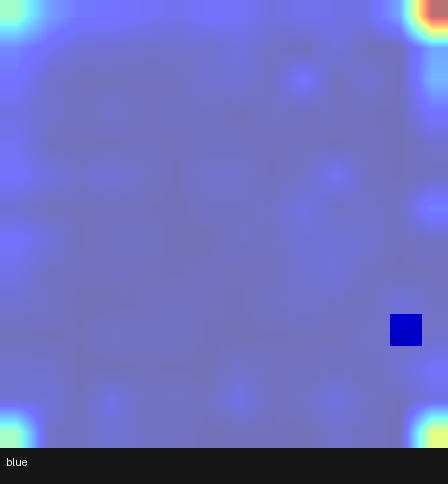

In [7]:
from IPython.display import Image as IPImage, display

attn = report.get('attention_test', {})
if attn.get('status') == 'passed' and attn.get('gif_path'):
    print('Attention GIF:', attn['gif_path'])
    display(IPImage(filename=attn['gif_path']))
else:
    print('Attention test status:', attn.get('status'))
    print('Reason:', attn.get('reason', ''))